###Description: This notebook implements and evaluates a multi-class classification model using the Pocket Perceptron algorithm on the Fashion MNIST dataset. It involves data preprocessing, training 10 one-vs-all binary classifiers, and assessing their performance with micro-averaged metrics and visualization of weight vector norms.

In [ ]:
# imports
from tensorflow.keras.datasets import fashion_mnist
import numpy as np
import itertools
from tqdm import tqdm, trange
from tqdm.contrib import tzip
import time
import pandas as pd
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt
mpl.style.use(['ggplot'])
# %matplotlib inline
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Load dataset
(X_train_origin, Y_train_origin), (X_test_origin, Y_test_origin) = fashion_mnist.load_data()
X_train = X_train_origin.copy()
Y_train = Y_train_origin.copy()
X_test = X_test_origin.copy()
Y_test = Y_test_origin.copy()
print("Training set:", X_train.shape, Y_train.shape)
print("Test set:", X_test.shape, Y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training set: (60000, 28, 28) (60000,)
Test set: (10000, 28, 28) (10000,)


**EDA**

I make this example to plot the images and see how the dataset looks like:

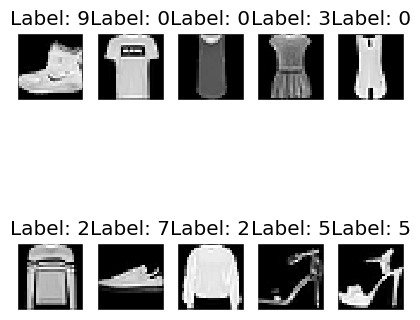

In [ ]:
# print 10 first items in X_train:
fig, axes = plt.subplots(2, 5, figsize=(5,5))
for i, ax in enumerate(axes.flatten()):             # no need for tqdm here
    ax.imshow(X_train[i], cmap='gray', interpolation='none')
    ax.set_title("Label: {}".format(Y_train[i]))
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

**Label and Image Transformation**
I will plot every pixel value and later on we will comapre the normalize pixels to the origin.

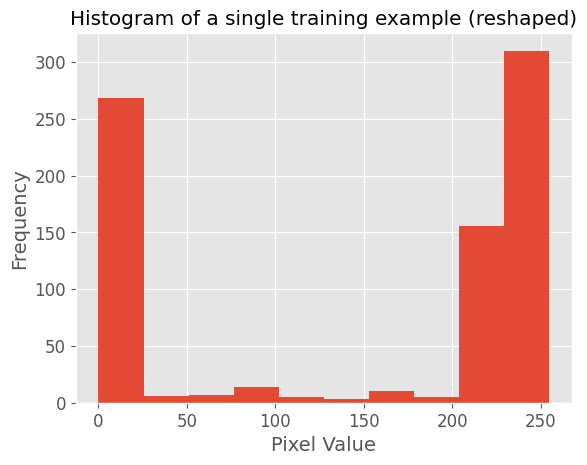

In [ ]:
example_image = X_train[7]
reshaped_example = example_image.reshape(-1) # Numpy effectively flattens the multi-dimensional array into a 1-dimensional array
plt.hist(reshaped_example)
plt.title("Histogram of a single training example (reshaped)")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

**Flattening Images and Normalizations**

In [ ]:
X_train = X_train.reshape(X_train.shape[0], 784).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], 784).astype('float32') / 255
# ML models typically perform calculations using floating-point numbers.
# Converting to float32 ensures that the data is in the correct format for the model and can help with numerical stability during training.

# Normalizing by 255 scales these values to a range between 0 and 1. This is a common practice in image processing bcz:
# It helps the optimization process converge faster.
# It prevents larger pixel values from dominating the learning process.
# It can improve the overall performance of the model.

# Add a column of ones for the bias term
X_train = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

# Example:
print("first sample shape: ", X_train[0].shape)
print("Augmented X shape: ",X_train.shape)

first sample shape:  (785,)
Augmented X shape:  (60000, 785)


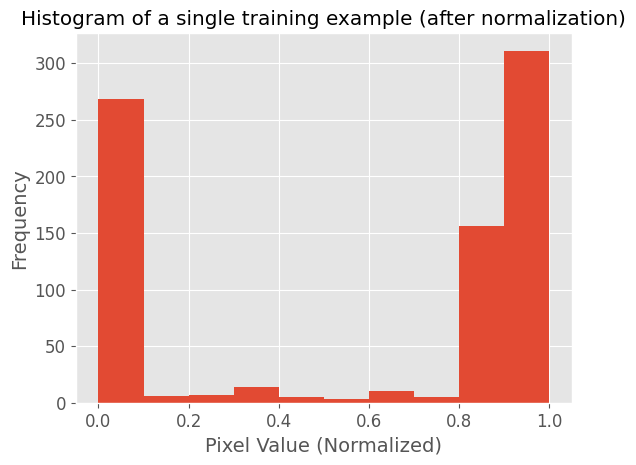

In [ ]:
# Example:
plt.hist(X_train[7])
plt.title("Histogram of a single training example (after normalization)")
plt.xlabel("Pixel Value (Normalized)")
plt.ylabel("Frequency")
plt.show()

So, we got the same plot, but normalized.

**One-Hot Encoding of Labels**

In [ ]:
n_classes = 10
print("Shape before one-hot encoding: ", Y_train.shape)

Y_train = np.zeros((Y_train_origin.shape[0], n_classes), dtype=np.float32)
Y_train[np.arange(Y_train_origin.shape[0]), Y_train_origin] = 1.0

Y_test = np.zeros((Y_test_origin.shape[0], n_classes), dtype=np.float32)
Y_test[np.arange(Y_test_origin.shape[0]), Y_test_origin] = 1.0

print("Shape after one-hot encoding: ", Y_train.shape)

Shape before one-hot encoding:  (60000,)
Shape after one-hot encoding:  (60000, 10)


Let's see if we got what we expected to have:

In [ ]:
print(Y_train_origin[7])
print(Y_train[7,:])

2
[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


**Binary Classification Setup:**

In the first stage, we create a binary classifier **to distinguish between the '0' class and all other**
classes. We assign the label +1 to examples labeled '0' and -1 to examples labeled '1', '2', ..., '9'.
The weight vector obtained from this classification is denoted as $W^0$



In [ ]:
# This is an example:
# Create binary labels for '0' vs 'all others'
Y_train_binary = np.where(Y_train_origin == 0, 1, -1)
Y_test_binary = np.where(Y_test_origin == 0, 1, -1)

# Initialize the weight vector (w_0) for the binary classifier (0 vs others)
# The size should be equal to the number of features in X_train (including the bias term)
w_0 = np.zeros(X_train.shape[1])

print("Shape of Y_train_binary:", Y_train_binary.shape)
print("Shape of w_0 (initial weight vector):", w_0.shape)
print("Example of +1 label: Y_train_binary[2] =", Y_train_binary[2])

Shape of Y_train_binary: (60000,)
Shape of w_0 (initial weight vector): (785,)
Example of +1 label: Y_train_binary[2] = 1


**Iterative Binary Problems:**

The weight vectors resulting from these binary classifications are denoted as $W^1, W^2, ..., W^9$

I chose to implement by creating structural classes.


I chose 1000 as the number of iteration, after i tried 200, 300 and 400 and saw that the model becomes better and better. In the end of the notebook i will plot the learning rate of the model.

In [ ]:
# define over-all variables
# The size should be equal to the number of features in X_train (including the bias term)
N_FEATURES = 785
# n_classes = 10
N_ITERATIONS = 1000

Note: *for a single vector or a batch matrix, np.dot(X, self.w) is the idiomatic and efficient way to compute $\mathbf{w}^T \mathbf{x}$ when $\mathbf{x}$ is defined as a row vector.

In [ ]:
class PocketPerceptron:
    """
    Pocket Perceptron Algorithm for binary classification, robust to
    non-linearly separable data by maintaining the best weight vector found.
    """
    def __init__(self, n_features, n_iterations):
        # Initialize weights (w) to zeros
        self.w = np.zeros(n_features)           # Current working weight vector (w_t)
        self.w_pocket = np.copy(self.w)         # Best weight vector found so far (w_pocket)
        self.best_error_count = float('inf')    # Error count for w_pocket
        self.n_iterations = n_iterations
        self.weights_history = [] # Store weights at each sampling interval

    def predict(self, X, weights=None):
        """Calculates the prediction using the specified or current weights."""
        if weights is None:
            weights = self.w # Default to the current working weights

        # The prediction is simply the sign of the dot product: w.T * X , where X is (785,)
        linear_output = np.dot(X, weights) # note*
        # Use np.sign() to get +1 or -1 prediction. If 0, it defaults to 0.
        return np.sign(linear_output) #(785,)


    def evaluate_error(self, X, y, weights):
        """Calculates the number of misclassifications for a given weight vector."""
        predictions = self.predict(X, weights) # output: (785,)
        # Count where target label y does NOT equal the prediction
        error_count = np.sum(predictions != y) # for example: (0 != +1)
        return error_count

    # here we will get y as Y_train_binary (+1 or -1) , X is the augmented data (e.g., 60000 x 785), out X_train
    def fit(self, X, y):
        """Trains the perceptron with the pocket mechanism."""

        # --- Initialization Step (t=0): ---
        # Set the initial pocket weight vector based on initial w (all zeros).
        # We must calculate the error for the initial w.
        self.best_error_count = self.evaluate_error(X, y, self.w_pocket)
        print(f"Initial Error Count: {self.best_error_count}")

        # PLA runs for one update to obtain w_t+1
        for iteration in trange(self.n_iterations):
            # --- PLA Step: Find one misclassified point and update w ---

            # Find all misclassified points
            predictions = self.predict(X, self.w)
            # finds the indices that the current Perceptron weight vector (self.w) classified incorrectly.
            misclassified_indices = np.where(predictions != y)[0] # Example: np.where([False, True, True]) returns (array([1, 2]),), and [0] returns the first and only element array([1, 2]), since its 1D.

            if len(misclassified_indices) == 0:
                print(f"Current PLA vector converged at iteration {iteration + 1}.")
                # Since the current w is perfect, it is the best, and we can stop
                self.w_pocket = np.copy(self.w)
                self.best_error_count = 0
                break

            # Randomly pick one misclassified point (standard PLA procedure)
            i = np.random.choice(misclassified_indices)
            xi, target = X[i], y[i]

            # Run PLA for one update (w_new = w_old + y*x)
            self.w += (target * xi) # w is now w_t+1

            # --- Pocket Algorithm Step: Evaluation and Update ---

            # Evaluate the performance of the new current weight vector (w_t+1)
            current_error_count = self.evaluate_error(X, y, self.w)

            # If current_error_count is better than best_error_count, update the pocket
            if current_error_count < self.best_error_count:
                # Set w_pocket to w (w_pocket <--- w_t+1)
                self.w_pocket = np.copy(self.w)
                self.best_error_count = current_error_count
                print(f"  Pocket updated: Iteration {iteration + 1} with error count {current_error_count}")

            if (iteration % 100 == 0):
                # Store a copy of the current best weights
                self.weights_history.append(self.w_pocket.copy())

        # # Add the best weight vector found to weights_history
        # self.weights_history.append(self.w_pocket.copy())  -- we will pass this because I will take iterations that are multiples of 100.

        # Return the best weight vector found
        return self.w_pocket, self.weights_history

# --- End of PocketPerceptron Class ---

**One-vs-All Training Loop:**

In [ ]:
# Dictionary to store the 10 trained Perceptron objects
# Each Perceptron object will contain its weights_history attribute in order to plot the learning rate
trained_classifiers = {}
w_history = {}

# K=10 classes (digits 0 through 9)
for class_label in tqdm(range(n_classes)):
    print(f"Training One-vs-All classifier for class {class_label}...")

    # --- Step 1: Create Binary Labels (One-vs-All) ---
    # --- (+1 for current class, -1 for all others) ---
    Y_train_binary = np.where(Y_train_origin == class_label, 1, -1)

    # --- Step 2: Initialize and Train the Binary Pocket Perceptron ---

    # Create a new Perceptron model for this specific binary problem
    model = PocketPerceptron(n_features=N_FEATURES, n_iterations=N_ITERATIONS)

    # Train the model
    best_w, w_hist = model.fit(X_train, Y_train_binary)

    # Store the trained model and the weights_history
    trained_classifiers[class_label] = best_w
    w_history[class_label] = w_hist

print("\nTraining complete. Stored 10 Perceptron models with weight histories.")
# --- End of Training ---

  0%|          | 0/10 [00:00<?, ?it/s]

Training One-vs-All classifier for class 0...
Initial Error Count: 60000



  0%|          | 2/1000 [00:00<00:54, 18.23it/s]

  Pocket updated: Iteration 1 with error count 6000



  1%|          | 12/1000 [00:00<00:57, 17.21it/s]

...

  Pocket updated: Iteration 766 with error count 868
  Pocket updated: Iteration 769 with error count 860



 81%|████████▏ | 814/1000 [00:55<00:12, 15.34it/s]

  Pocket updated: Iteration 811 with error count 838



100%|██████████| 10/10 [11:23<00:00, 68.36s/it]


Training complete. Stored 10 Perceptron models with weight histories.


**Prediction:**

$\hat y=argmax_y (W^y*X$)

In [ ]:
def multi_class_prediction(X, classifiers):
  """
    Makes multi-class predictions by selecting the classifier with the highest activation score.
    Input: X_test (?? , 765), and (trained) classifiers (dict)
    Output: y_pred (??,)
  """
  # Create a matrix of all 10 weight vectors (10 x 785)
  W_matrix = np.array([classifiers[n] for n in range(n_classes)])

  # Calculate all 10 activation scores for every input example
  scores = np.dot(X, W_matrix.T)   # Scores shape: (N_examples x 10), we used again only x rows to efficiency calculation

  # The prediction is the index (class label) of the maximum score
  return np.argmax(scores, axis=1) # If axis=1, it returns the *_index_* of the maximum along the row. Output: (??,)

**Model Evaluation:**

In [ ]:
def stats(y_true, y_pred):
  """
      Calculates micro-averaged performance metrics for a multi-class classification problem.
      input: y_true (array-like): True labels, y_pred (array-like): Predicted labels.
      output: TN, FP, FN, TP, Se, Sp, PPV, NPV, Acc, F1 (all micro-averaged),
              and class_sensitivities (array of sensitivities for each class).
  """
  cm = confusion_matrix(y_true, y_pred) # The function returns a NumPy array representing the confusion matrix
  num_classes = n_classes # Using the global n_classes (10)
  total_samples = len(y_true)

  TP_sum = 0
  FP_sum = 0
  FN_sum = 0
  TN_sum = 0

  class_TPs = np.zeros(num_classes)
  class_FNs = np.zeros(num_classes)
  class_sensitivities = np.zeros(num_classes)

  for i in trange(num_classes):
      # One-vs-Rest calculation for class i
      tp = cm[i, i]
      fp = np.sum(cm[:, i]) - tp  # Sum of column i (predicted as i) - true positive i
      fn = np.sum(cm[i, :]) - tp  # Sum of row i (actual i) - true positive i
      tn = total_samples - (tp + fp + fn) # Total samples - (TP_i + FP_i + FN_i)

      TP_sum += tp
      FP_sum += fp
      FN_sum += fn
      TN_sum += tn

      class_TPs[i] = tp
      class_FNs[i] = fn
      class_sensitivities[i] = tp / (tp + fn) if (tp + fn) > 0 else 0

  # Assign micro-averaged components
  TP = TP_sum
  FP = FP_sum
  FN = FN_sum
  TN = TN_sum

  # Calculate metrics using the provided formulas
  # Handle division by zero for robustness
  Se = TP / (TP + FN) if (TP + FN) > 0 else 0
  Sp = TN / (TN + FP) if (TN + FP) > 0 else 0
  PPV = TP / (TP + FP) if (TP + FP) > 0 else 0
  NPV = TN / (TN + FN) if (TN + FN) > 0 else 0
  Acc = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
  F1 = (2*Se*PPV) / (Se+PPV) if (Se+PPV) > 0 else 0

  return TN, FP, FN, TP, Se, Sp, PPV, NPV, Acc, F1, class_sensitivities

100%|██████████| 10/10 [00:00<00:00, 33961.98it/s]


Performance metrics:


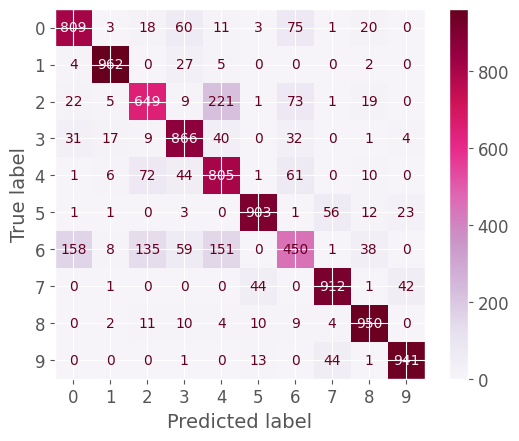

Performance metrics - micro-averaged:
Sensitivity is 0.8247. 
Specificity is 0.9805. 
PPV is 0.82. 
NPV is 0.9805. 
Accuracy is 0.9649. 
F1 is 0.8247. 

Sensitivity for each class (True Positive Rate, TPR):
Class 0: 0.8090
Class 1: 0.9620
Class 2: 0.6490
Class 3: 0.8660
Class 4: 0.8050
Class 5: 0.9030
Class 6: 0.4500
Class 7: 0.9120
Class 8: 0.9500
Class 9: 0.9410


In [ ]:
y_pred = multi_class_prediction(X_test, trained_classifiers)

# Calculate Stats:
TN, FP, FN, TP, Se, Sp, PPV, NPV, Acc, F1, class_sensitivities = stats(Y_test_origin, y_pred)
print("Performance metrics:")

ConfusionMatrixDisplay.from_predictions(Y_test_origin, y_pred, cmap='PuRd')
plt.title("")
plt.show()

print("Performance metrics - micro-averaged:")
print('Sensitivity is {:.4f}. \nSpecificity is {:.4f}. \nPPV is {:.2f}. \nNPV is {:.4f}. \nAccuracy is {:.4f}. \nF1 is {:.4f}. '.format(Se,Sp,PPV,NPV,Acc,F1))

print("\nSensitivity for each class (True Positive Rate, TPR):")
for i, sens in enumerate(class_sensitivities):
    print(f"Class {i}: {sens:.4f}")

Discussions:
1. The model’s overall accuracy (as the proportion of correctly classified samples out of all test samples) is: 96.49%. we can valid our result by taking a quick look at the GitHub "repo" of the MNIST, where it been said that "Classic machine learning algorithms can also achieve 97% easily".

2. As reflects from confusion matrix, there are several classes that are much harder to classify by our model. We can see it by looking at thier poor model's Senseticity rate. The hardest categories clothes to classify are:
6 shirt, 2 pullover, 4 coat, 0 t-shirts/top, which gained: 45.0%, 64.9%, 80.5%, 80.9% respectively, while the rest got 90% and above.

3. For me it makes sense that the model will be confused by these specific classes, because they are all look the same in general: they cover the upper body and the sleeves, thus the shapes of the general pixels that are white compared to black is very similar. If we take a shoe, for example, the genral shape will be much different from a t-shirt.

(2.) The easiest to classify is the trouser (96.2%), and right after is the bag (95.0%). This results are also make sense, because the same reason we mentioned: there are no other items that are looks similer to the bag or the trouser.

L2 norms calculated for all classifiers.


/tmp/ipython-input-3703037686.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes) # 'tab10' provides 10 distinct colors


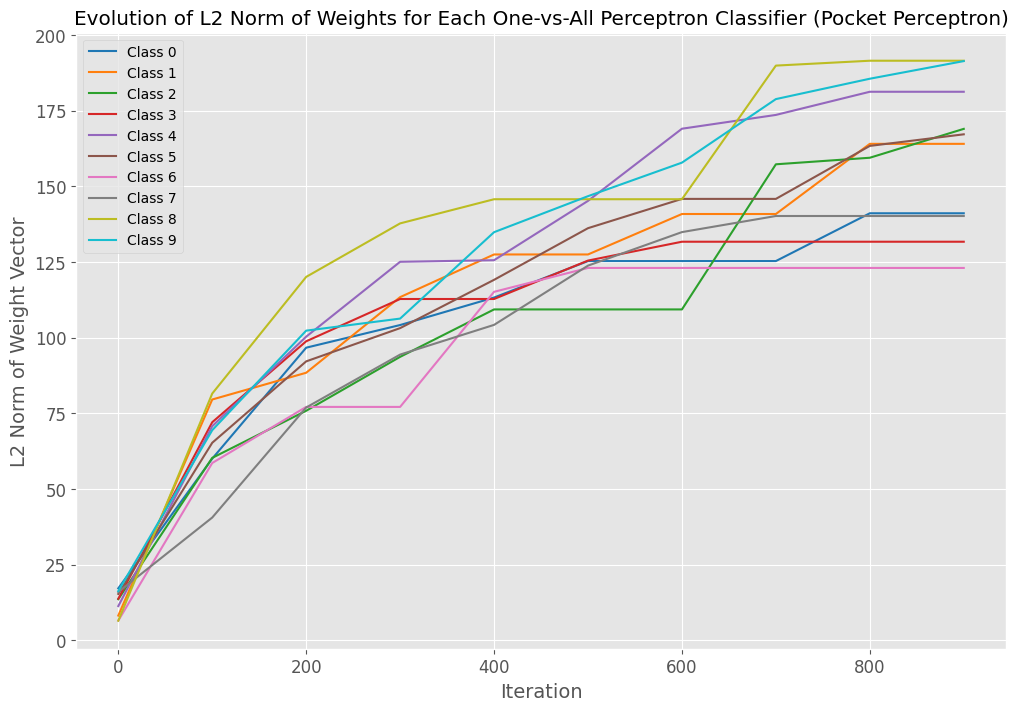

In [ ]:
#@title: weights learning rate cell
# Calculate L2 norms for the weights history of each classifier

l2_norms_history = {}

for class_label, history in w_history.items():
    # Calculate L2 norm for each weight vector in the history
    # np.linalg.norm(w) computes the L2 norm (Euclidean norm) by default
    norms = [np.linalg.norm(w_vector) for w_vector in history]
    l2_norms_history[class_label] = norms

print("L2 norms calculated for all classifiers.")
# Example for class 0:
# print(f"L2 norms for class 0: {l2_norms_history[0][:5]}...")

# Plot the L2 norms of the weights over iterations
plt.figure(figsize=(12, 8))

# Generate iteration labels for the x-axis
# The weights were sampled every 100 iterations, starting from iteration 0.
# The number of samples is len(l2_norms_history[class_label]), so iterations are [0, 100, 200, ...]
# Account for the possibility that the last iteration might not be a multiple of 100  (not needed for 1000 iteration)
num_samples = len(list(l2_norms_history.values())[0])
iterations = np.arange(num_samples) * 100

# Get a colormap with enough distinct colors for all classes
colors = plt.cm.get_cmap('tab10', n_classes) # 'tab10' provides 10 distinct colors

for class_label, norms in l2_norms_history.items():
    plt.plot(iterations, norms, label=f'Class {class_label}', color=colors(class_label))

plt.title('Evolution of L2 Norm of Weights for Each One-vs-All Perceptron Classifier (Pocket Perceptron)')
plt.xlabel('Iteration')
plt.ylabel('L2 Norm of Weight Vector')
plt.legend(loc='best')
plt.grid(True)
plt.show()